<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B8%B0%EB%B0%98%ED%97%AC%EC%8A%A4%EC%BC%80%EC%96%B4%EA%B8%B0%EC%88%A0/analysis_avocado_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

설정된 폰트: ['NanumBarunGothic']


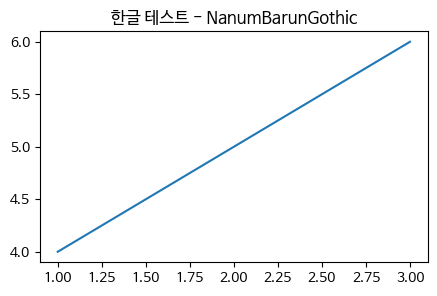

In [115]:


#한글 폰트 설치 (실행 후 런타임 다시 시작 필요)

# --------- 폰트 설치용. 주석 해제 후 폰트 설치하면 됩니다 --------- #

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] = False



# --------- 폰트 설치 테스트. 발표 자료에는 해당 내용 적을 필요 없음 ---------- #
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 설치된 나눔 폰트 경로 확인
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 매니저에 폰트 추가 및 캐시 업데이트
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 설정 확인 (NanumBarunGothic이 출력되어야 함)
print(f"설정된 폰트: {plt.rcParams['font.family']}")

# 테스트 차트
plt.figure(figsize=(5,3))
plt.title('한글 테스트 - NanumBarunGothic')
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [116]:
import pandas as pd
df = pd.read_csv('/content/sample_data/avocado.csv')

display(df.head()) #avocado 파일의 각 컬럼 의미 파악 및 데이터 파악

df.info() #컬럼 개수 및 의미 파악
df.isnull().sum() #결측치 파악

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


,0
Unnamed: 0,0
Date,0
AveragePrice,0
Total Volume,0
4046,0
4225,0
4770,0
Total Bags,0
Small Bags,0
Large Bags,0


In [117]:
print(df.columns)

Index(['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225',
       '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type',
       'year', 'region'],
      dtype='object')


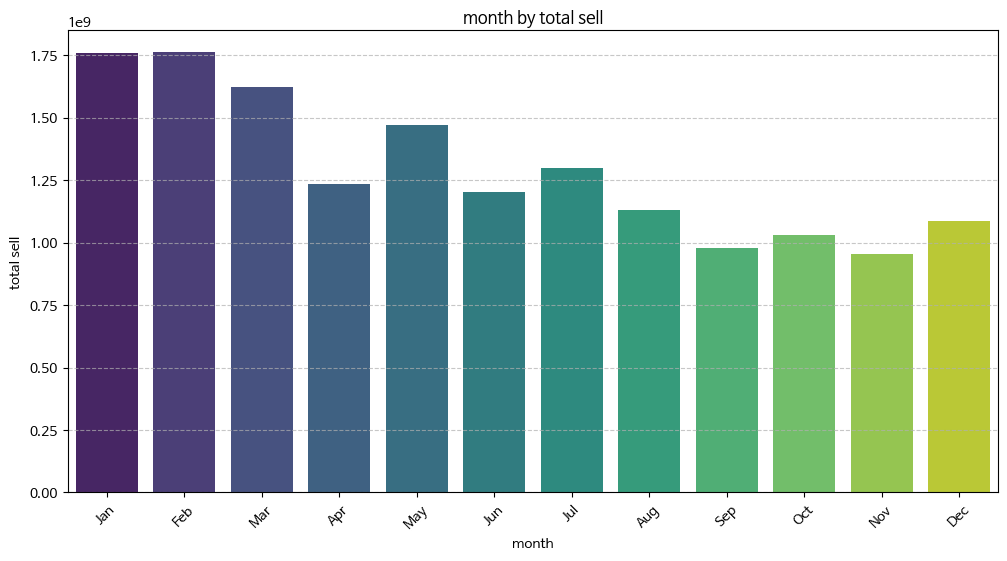

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Date'] = pd.to_datetime(df['Date'])

# 월과 요일 추출
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # Monday=0, Sunday=6

# 월별 판매량 집계
monthly_sales = df.groupby('Month')['Total Volume'].sum().reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales['MonthName'] = monthly_sales['Month'].map(lambda x: month_names[x-1])

# 월별 판매량
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='MonthName', y='Total Volume', data=monthly_sales, ax=ax, palette='viridis', hue='MonthName', legend=False)
ax.set_title('month by total sell')
ax.set_xlabel('month')
ax.set_ylabel('total sell')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

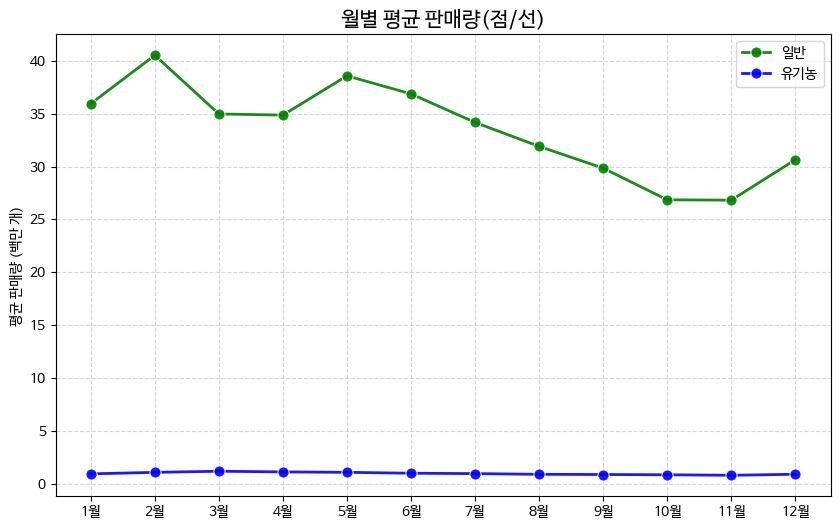

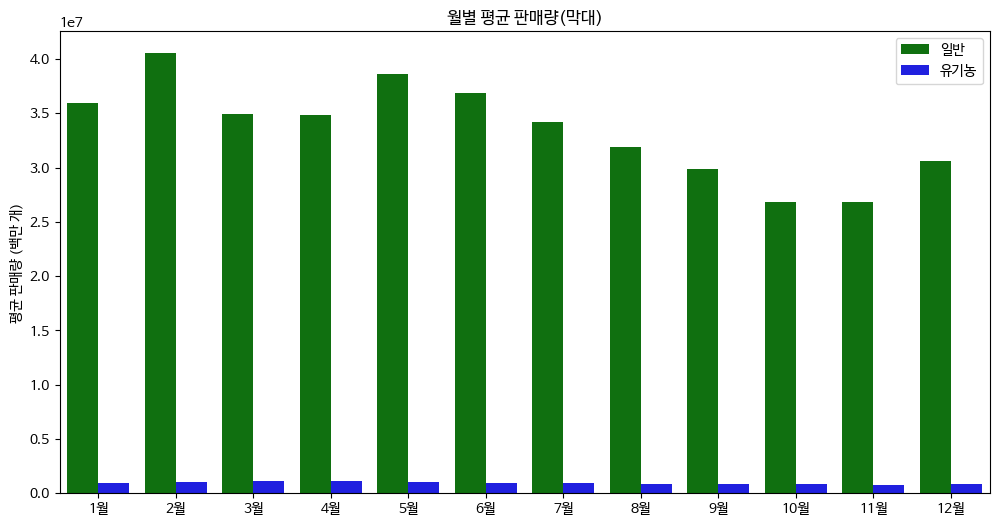

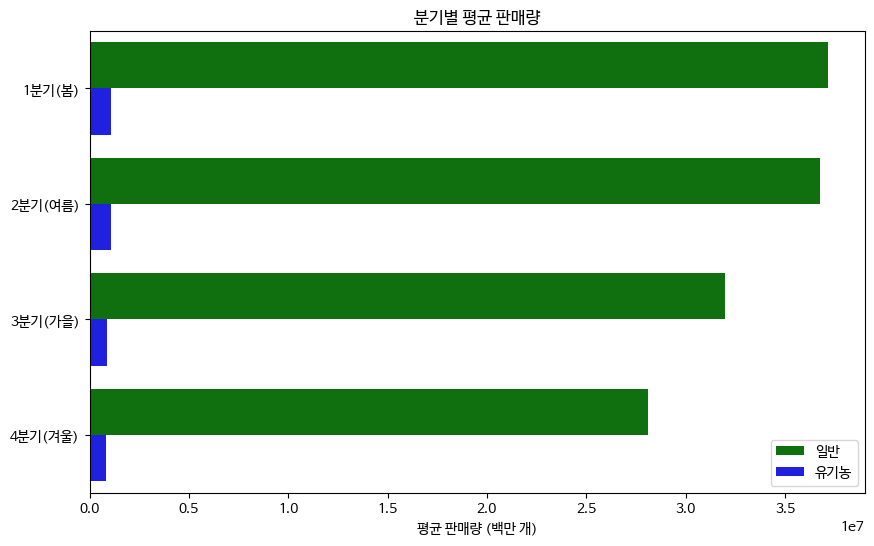

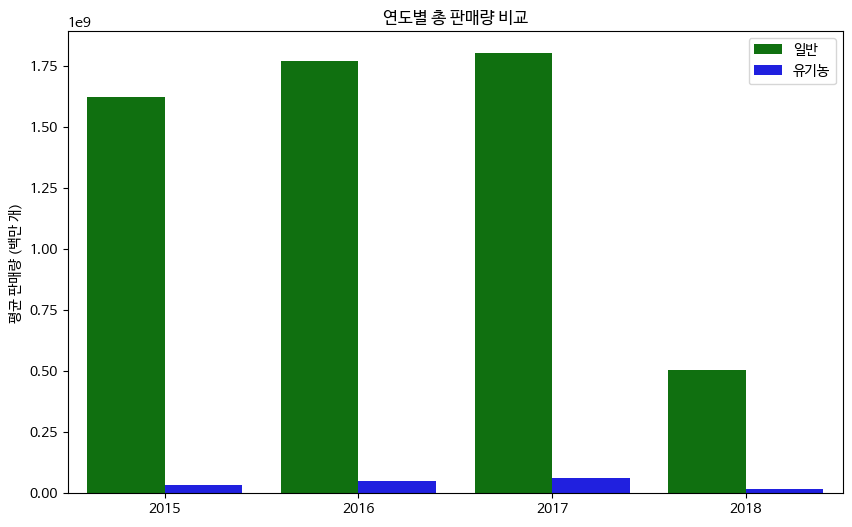

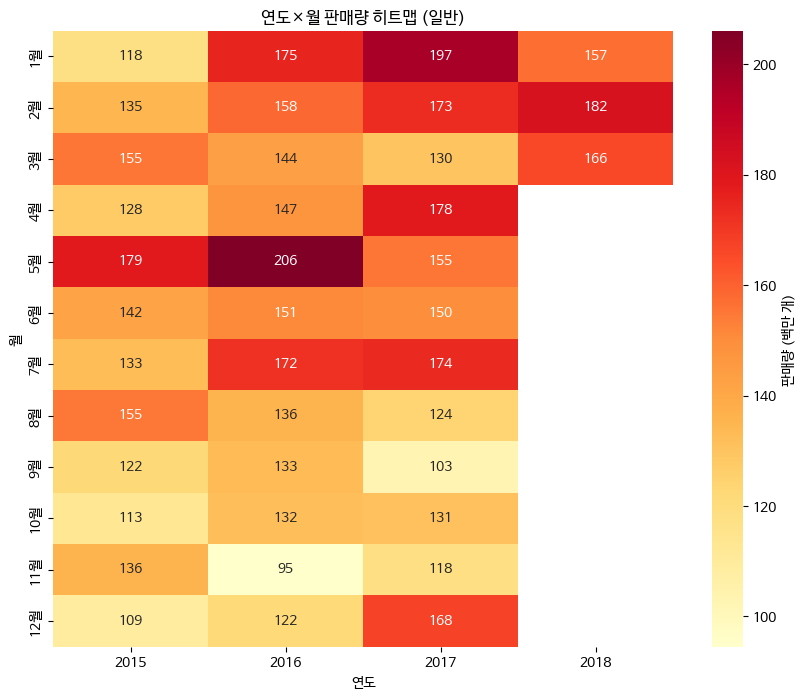

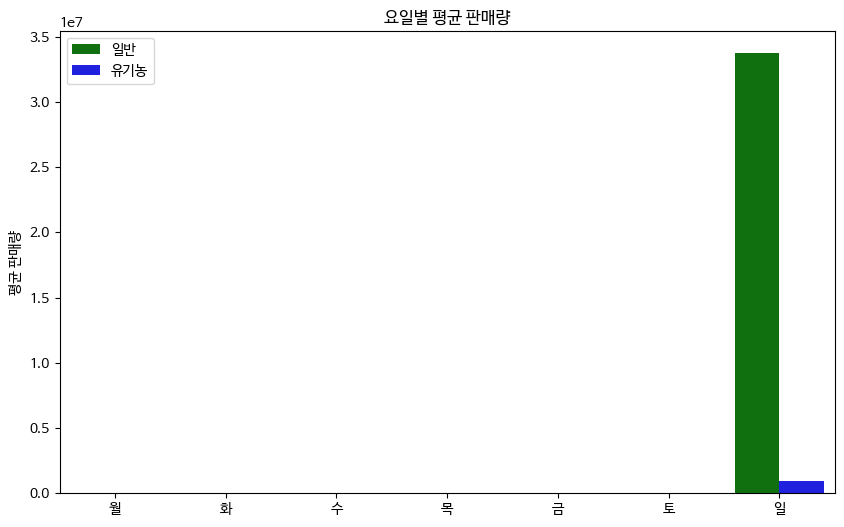

In [138]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#/content/sample_data/ 경로에 avocado.csv 파일 불러오기
df = pd.read_csv("/content/sample_data/avocado.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df.drop(columns=["Unnamed: 0"], inplace=True)
df.dropna(subset=["Date"], inplace=True)

# 이상치 제거 : 전체 판매량(Total Volume)과 평균 가격(AveragePrice)이 0보다 큰 데이터만 사용
df = df[df["Total Volume"] > 0]
df = df[df["AveragePrice"] > 0]

# 전국 합계 데이터 사용(전국단위로 연도별/월별/요일별 평균 판매량을 확인하기 위해 불필요한 각 지역별 데이터는 사용하지 않음)
us = df[df["region"] == "TotalUS"].copy()

# 월별 평균 판매량
monthly_avg = (
    us.groupby([us["Date"].dt.month.rename("month"), "type"])["Total Volume"]
    .mean()
    .reset_index()
    .rename(columns={"Total Volume": "vol"})
)

# 요일별 평균 판매량
dow_avg = (
    us.groupby([us["Date"].dt.dayofweek.rename("dow"), "type"])["Total Volume"]
    .mean()
    .reset_index()
    .rename(columns={"Total Volume": "vol"})
)

# 히트맵용 데이터
hmap = (
    us[us["type"] == "conventional"]
    .groupby([us["Date"].dt.month.rename("month"),
              us["Date"].dt.year.rename("year")])["Total Volume"]
    .sum()
    .unstack("year")
    / 1000000
)

# 연도별 총 판매량 비교
annual = (
    us.groupby([us["Date"].dt.year.rename("year"), "type"])["Total Volume"]
    .sum()
    .reset_index()
    .rename(columns={"Total Volume": "vol"})
)


## -------------------- 그래프 그리기 ----------------- ###

TYPE_KR = {"conventional": "일반", "organic": "유기농"}
COLORS = {"일반": "g", "유기농": "b"}
MONTH_LABELS = ["1월","2월","3월","4월","5월","6월",
                "7월","8월","9월","10월","11월","12월"] #X축 1~12월 명시
DOW_LABELS   = ["월","화","수","목","금","토","일"]  #X축 요일명(월~일) 명시

# 데이터프레임의 type을 한글로 변환(conventional -> 일반, organic -> 유기농)
monthly_avg['type'] = monthly_avg['type'].map(TYPE_KR)
annual['type'] = annual['type'].map(TYPE_KR)

#1.월별 평균 판매량(seaborn의 lineplot을 사용)
#2월 판매량이 가장 높고 10월과 11월 판매량이 가장 낮음
plt.figure(figsize=(10, 6))
for atype_eng, atype_kr in TYPE_KR.items():
    sub = monthly_avg[monthly_avg['type'] == atype_kr].sort_values('month')
    sns.lineplot(x=sub['month'], y=sub['vol'] / 1e6, color=COLORS[atype_kr],
                 marker='o', markersize=8, linewidth=2, alpha=0.9, label=atype_kr)
plt.title('월별 평균 판매량(점/선)', fontsize=15)
plt.xticks(range(1, 13), MONTH_LABELS)
plt.xlabel('')
plt.ylabel('평균 판매량 (백만 개)')
plt.legend(title=None)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#2.월별 평균 판매량(seaborn의 barplot을 사용)
#2월 판매량이 가장 높고 10월과 11월 판매량이 가장 낮음
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_avg, x='month', y='vol', hue='type', palette=COLORS)
plt.title('월별 평균 판매량(막대)')
plt.xticks(range(0, 12), MONTH_LABELS)
plt.xlabel('')
plt.ylabel('평균 판매량 (백만 개)')
plt.legend(title=None)
plt.show()

#3.분기별 평균 판매량(seaborn의 barplot을 사용)
#1분기(봄) 판매율이 가장 높고 4분기(겨울) 판매율이 가장 낮다
#판매율 순위 : 봄 > 여름 > 가을 > 겨울
monthly_avg['Quarter'] = ((monthly_avg['month'] - 1) // 3 + 1).map({1: '1분기(봄)', 2: '2분기(여름)', 3: '3분기(가을)', 4: '4분기(겨울)'}) #분기 계산식
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_avg, y='Quarter', x='vol', hue='type', palette=COLORS, orient='h', errorbar=None)
plt.xlabel('평균 판매량 (백만 개)')
plt.ylabel('')
plt.title('분기별 평균 판매량')
plt.legend(title=None)
plt.show()

#4.연도별 총 판매량 비교(seaborn의 barplot을 사용)
#2015 ~ 2018년 총 4년간 판매량 중 2017년이 판매량이 가장 높고 2018년이 가장 낮다.
plt.figure(figsize=(10, 6))
sns.barplot(data=annual, x='year', y='vol', hue='type', palette=COLORS)
plt.title('연도별 총 판매량 비교')
plt.xlabel('')
plt.ylabel('평균 판매량 (백만 개)')
plt.legend(title=None)
plt.show()

# 5. 연도×월 히트맵
# 1월 기준으로는 2017년 > 2016년 > 2018년 > 2015년 순서로 아보카도 판매량 순위 확인이 가능하다
# 2017년 기준으로는 1월이 197로 가장 판매량이 높고 9월이 103으로 판매량이 가장 낮다

# 전체 판매량 기준으로는
# 2016년 5월이 206으로 가장 판매량이 높다 (2016년 5월은 봄으로 분기별 판매 추이에서 봄이 가장 판매량이 많은것과 연계가능)
# 2016년 11월이 95로 가장 판매량이 낮다(2016년 11월은 겨울로 분기별 판매 추이에서 겨울이 가장 판매량이 낮은것과 연계가능)
plt.figure(figsize=(10, 8))
sns.heatmap(hmap, annot=True, fmt='.0f', cmap='YlOrRd', yticklabels=MONTH_LABELS, cbar_kws={'label': '판매량 (백만 개)'})
plt.title('연도×월 판매량 히트맵 (일반)')
plt.xlabel('연도')
plt.ylabel('월')
plt.show()

# 6. 요일별 평균 판매량 : 확인불가. TotalUS 뿐 아니라 모든 지역의 데이터는 일요일에만 집계되므로 요일별 평균 판매량 확인이 어렵다.
# 일요일 데이터만 확인 가능 따라서 각 요일(월~일)별 평균 판매량 확인이 불가함
all_days = pd.DataFrame({'dow': range(7)})
all_types = pd.DataFrame({'type': ['conventional', 'organic']})
full_index = all_days.merge(all_types, how='cross')
dow_plot_df = pd.merge(full_index, dow_avg, on=['dow', 'type'], how='left').fillna(0)
dow_plot_df['type'] = dow_plot_df['type'].map(TYPE_KR)

plt.figure(figsize=(10, 6))
ax6 = sns.barplot(data=dow_plot_df, x='dow', y='vol', hue='type', palette=COLORS)
plt.title('요일별 평균 판매량')
ax6.set_xticks(range(7))
ax6.set_xticklabels(DOW_LABELS)
ax6.set_xlabel('')
plt.ylabel('평균 판매량')
plt.legend(title=None)
plt.show()

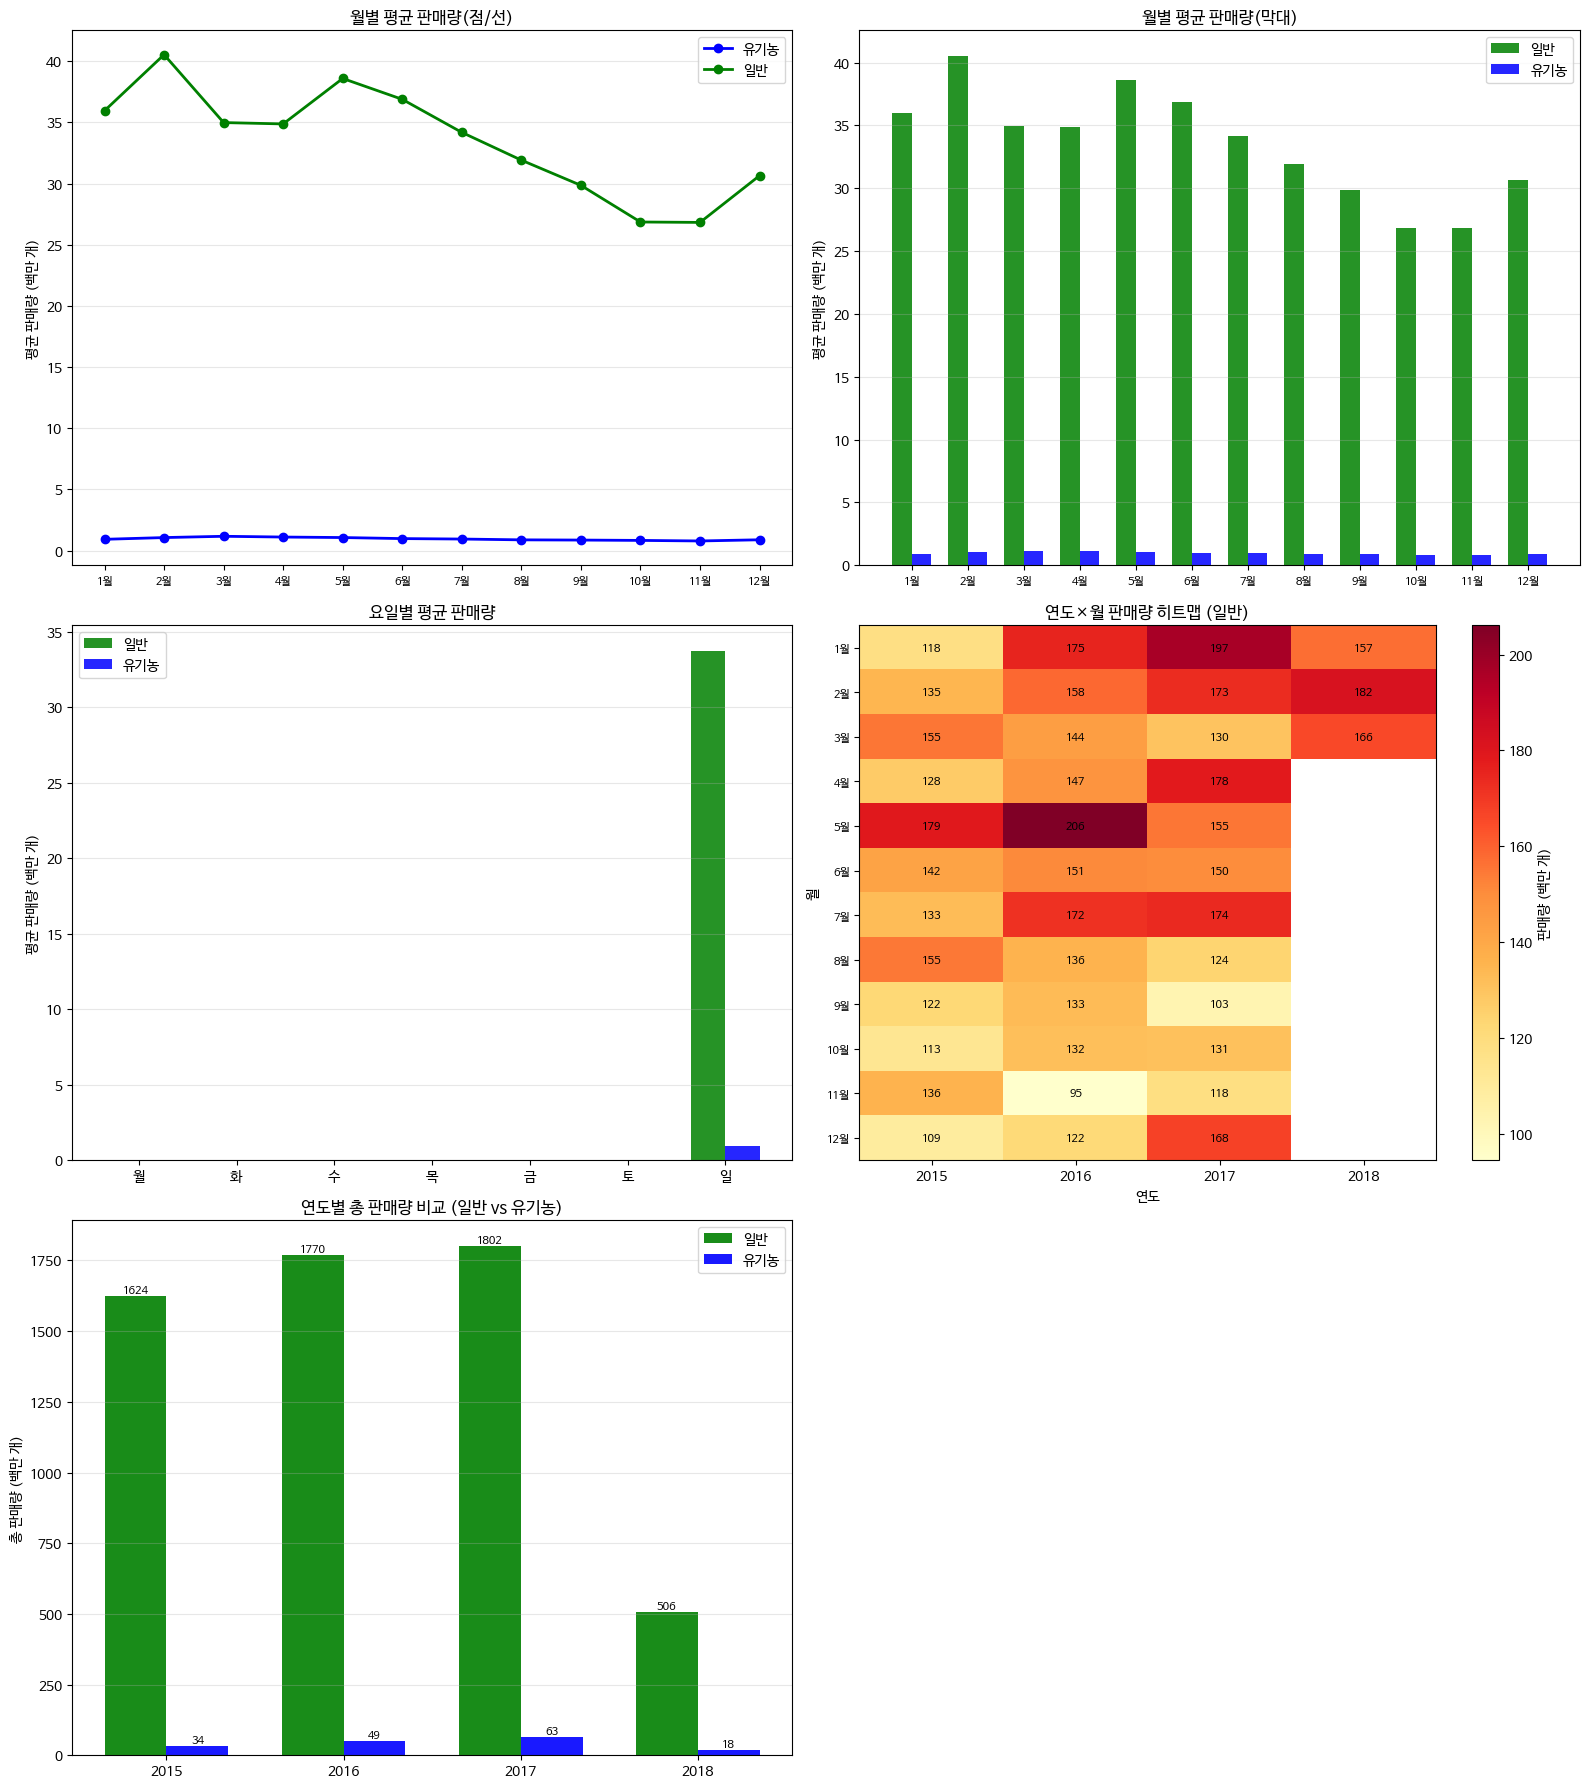

In [127]:
## ------------ subbplots을 사용하여 그래프를 한 눈에 보기 -------------- ##

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

#1.월별 평균 판매량 추이 (선 그래프)
ax = axes[0, 0]
for atype, grp in monthly_avg.groupby("type"):
    ax.plot(grp["month"], grp["vol"] / 1e6,
            marker="o", linewidth=2,
            label=atype, color=COLORS[atype])
ax.set_title("월별 평균 판매량(점/선)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS, fontsize=8)
ax.set_ylabel("평균 판매량 (백만 개)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

#2.월별 평균 판매량 (막대 그래프)
ax = axes[0, 1]
x = range(1, 13)
w = 0.35

for i, atype_kr in enumerate(["일반", "유기농"]):
    sub = monthly_avg[monthly_avg["type"] == atype_kr].sort_values("month")
    ax.bar([v + i * w for v in x], sub["vol"] / 1e6, w,
           label=atype_kr, color=COLORS[atype_kr], alpha=0.85)

ax.set_title("월별 평균 판매량(막대)")
ax.set_xticks([v + w/2 for v in x])
ax.set_xticklabels(MONTH_LABELS, fontsize=8)
ax.set_ylabel("평균 판매량 (백만 개)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

#3.요일별 평균 판매량
ax = axes[1, 0]
x = range(7)
w = 0.35

dow_plot_df_local = dow_plot_df.copy()
for i, atype_kr in enumerate(["일반", "유기농"]):
    sub = dow_plot_df_local[dow_plot_df_local["type"] == atype_kr].sort_values("dow")
    ax.bar([v + i * w for v in x], sub["vol"] / 1e6, w,
           label=atype_kr, color=COLORS[atype_kr], alpha=0.85)

ax.set_title("요일별 평균 판매량")
ax.set_xticks([v + w / 2 for v in x])
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel("평균 판매량 (백만 개)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

#4.연도×월 히트맵
ax = axes[1, 1]
data = hmap.values
im = ax.imshow(data, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="판매량 (백만 개)")

ax.set_xticks(range(len(hmap.columns)))
ax.set_xticklabels(hmap.columns.astype(int))
ax.set_yticks(range(len(hmap.index)))
ax.set_yticklabels(MONTH_LABELS, fontsize=8)
ax.set_title("연도×월 판매량 히트맵 (일반)")
ax.set_xlabel("연도")
ax.set_ylabel("월")

for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        v = data[r, c]
        if not pd.isna(v):
            ax.text(c, r, f"{v:.0f}", ha="center", va="center", fontsize=8, color="black")

#5.연도별 총 판매량 비교
ax = axes[2, 0]
years = sorted(annual["year"].unique())
x_years = range(len(years))
w = 0.35

for i, atype_kr in enumerate(["일반", "유기농"]):
    sub = annual[annual["type"] == atype_kr].sort_values("year")
    bars = ax.bar([v + i * w for v in x_years], sub["vol"] / 1e6, w,
                  label=atype_kr, color=COLORS[atype_kr], alpha=0.9)
    for bar, val in zip(bars, sub["vol"].values / 1e6):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.0f}",
                ha="center", va="bottom", fontsize=8)

ax.set_title("연도별 총 판매량 비교 (일반 vs 유기농)")
ax.set_xticks([v + w / 2 for v in x_years])
ax.set_xticklabels(years)
ax.set_ylabel("총 판매량 (백만 개)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# 사용하지 않는 마지막 서브플롯 숨기기
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()